In [1]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

from dataset import CoralDataModule
from model import CoralSegFormer
from matplotlib.colors import ListedColormap

In [2]:
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.enabled = False
torch.set_float32_matmul_precision("high")

In [3]:
user = "jrhowell"
dataset_dir = f"/home/{user}/sadow_koastore/shared/coral_seg/data/"
results_dir = f"/home/{user}/benthic_ecology_group/Jack/coral_seg/results/"
checkpoint_dir = f"{results_dir}/checkpoints_2.13.2026/"

# Pick the checkpoint you want to validate"
checkpoint_path = f"/home/{user}/benthic_ecology_group/Jack/coral_seg/results/checkpoints_2.13.2026/coral-segformer-epoch=01-val_loss=0.25.ckpt"

batch_size = 8
split_ratio = 0.8
num_workers = 4
samples_per_image = 100
crop_size = (512, 512)

device = "cuda" if torch.cuda.is_available() else "cpu"

print("Using device:", device)
print("Checkpoint path:", checkpoint_path)
print("Checkpoint exists:", Path(checkpoint_path).exists())

Using device: cuda
Checkpoint path: /home/jrhowell/benthic_ecology_group/Jack/coral_seg/results/checkpoints_2.13.2026/coral-segformer-epoch=01-val_loss=0.25.ckpt
Checkpoint exists: True


In [4]:
seed = 42
random.seed(seed)
np.random.seed(seed)
torch.manual_seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

print("Seed set to", seed)

Seed set to 42


In [5]:
data_module = CoralDataModule(
    root_dir=dataset_dir,
    batch_size=batch_size,
    split_ratio=split_ratio,
    num_workers=num_workers,
    samples_per_image=samples_per_image,
    crop_size=crop_size,
)

data_module.setup()

train_loader = data_module.train_dataloader()
val_loader = data_module.val_dataloader()

print("Number of validation image/mask pairs:", len(data_module.val_files))
print("Validation dataset length (random crops):", len(data_module.val_ds))
print("Validation batches:", len(val_loader))

Scanning /home/jrhowell/sadow_koastore/shared/coral_seg/data/...
Found 199 valid image/mask pairs.
Training on 159 images.
Validating on 40 images.
Number of validation image/mask pairs: 40
Validation dataset length (random crops): 4000
Validation batches: 500


In [6]:
example_batch = next(iter(val_loader))
images, masks = example_batch

print("Batch type:", type(example_batch))
print("Images shape:", images.shape)
print("Masks shape:", masks.shape)
print("Image dtype:", images.dtype)
print("Mask dtype:", masks.dtype)
print("Unique mask values in first batch:", torch.unique(masks))

Batch type: <class 'list'>
Images shape: torch.Size([8, 3, 512, 512])
Masks shape: torch.Size([8, 512, 512])
Image dtype: torch.float32
Mask dtype: torch.int64
Unique mask values in first batch: tensor([0, 1])


In [7]:
model = CoralSegFormer.load_from_checkpoint(checkpoint_path)
model.eval()
model.to(device)

print("Loaded checkpoint successfully")
print("Learning rate stored in checkpoint/model:", model.learning_rate)
print("Class mapping:", model.id2label)

Loading weights:   0%|          | 0/192 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/mit-b0
Key                                           | Status     | 
----------------------------------------------+------------+-
classifier.bias                               | UNEXPECTED | 
classifier.weight                             | UNEXPECTED | 
decode_head.linear_c.{0, 1, 2, 3}.proj.bias   | MISSING    | 
decode_head.linear_c.{0, 1, 2, 3}.proj.weight | MISSING    | 
decode_head.classifier.bias                   | MISSING    | 
decode_head.classifier.weight                 | MISSING    | 
decode_head.batch_norm.running_mean           | MISSING    | 
decode_head.batch_norm.running_var            | MISSING    | 
decode_head.batch_norm.num_batches_tracked    | MISSING    | 
decode_head.batch_norm.bias                   | MISSING    | 
decode_head.linear_fuse.weight                | MISSING    | 
decode_head.batch_norm.weight                 | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different ta

Loaded checkpoint successfully
Learning rate stored in checkpoint/model: 0.0003
Class mapping: {0: 'background', 1: 'nv', 2: 'nh', 3: 'hy', 4: 'st-zo'}


In [8]:
def get_logits(model, images):
    outputs = model(images)
    if hasattr(outputs, "logits"):
        return outputs.logits
    return outputs


def align_logits_to_masks(logits, masks):
    if logits.shape[-2:] != masks.shape[-2:]:
        logits = F.interpolate(
            logits,
            size=masks.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    return logits


def compute_iou(preds, targets, num_classes):
    ious = []
    for cls in range(num_classes):
        pred_cls = preds == cls
        target_cls = targets == cls

        intersection = (pred_cls & target_cls).sum().item()
        union = (pred_cls | target_cls).sum().item()

        if union == 0:
            ious.append(np.nan)
        else:
            ious.append(intersection / union)
    return ious


def denormalize_image(img_tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    img = img_tensor.detach().cpu() * std + mean
    img = img.clamp(0, 1).permute(1, 2, 0).numpy()
    return img


def class_names_from_model(model):
    return [model.id2label[i] for i in range(len(model.id2label))]

In [9]:
images, masks = next(iter(val_loader))

print("before move:", images.shape, images.dtype, masks.shape, masks.dtype)

images = images[:1].to(device)
masks = masks[:1].to(device)

print("after move:", images.shape, images.device)
print("model device:", next(model.parameters()).device)

with torch.no_grad():
    logits = get_logits(model, images)
    logits = align_logits_to_masks(logits, masks)
    preds = torch.argmax(logits, dim=1)

print("logits shape:", logits.shape)
print("preds shape:", preds.shape)
print("done")

before move: torch.Size([8, 3, 512, 512]) torch.float32 torch.Size([8, 512, 512]) torch.int64
after move: torch.Size([1, 3, 512, 512]) cuda:0
model device: cuda:0
logits shape: torch.Size([1, 5, 512, 512])
preds shape: torch.Size([1, 512, 512])
done


In [10]:
example_cache = []
num_examples = 4

model.eval()

total_batches = len(val_loader)
num_examples = min(num_examples, total_batches)
chosen_batches = set(random.sample(range(total_batches), k=num_examples))

with torch.no_grad():
    for b_idx, (images, masks) in enumerate(val_loader):
        if b_idx not in chosen_batches:
            continue

        images = images.to(device)
        masks = masks.to(device)

        logits = get_logits(model, images)
        logits = align_logits_to_masks(logits, masks)
        preds = torch.argmax(logits, dim=1)

        # pick one random tile from this batch
        i = random.randint(0, images.shape[0] - 1)

        example_cache.append({
            "image": images[i].detach().cpu(),
            "target": masks[i].detach().cpu(),
            "pred": preds[i].detach().cpu(),
        })

print("example_cache length:", len(example_cache))

example_cache length: 4


In [11]:
preds_list = []
targets_list = []

for sample in example_cache:
    preds_list.append(sample["pred"].unsqueeze(0))
    targets_list.append(sample["target"].unsqueeze(0))

all_preds = torch.cat(preds_list, dim=0)
all_targets = torch.cat(targets_list, dim=0)

num_classes = len(model.id2label)
class_names = class_names_from_model(model)

pixel_acc = (all_preds == all_targets).float().mean().item()
ious = compute_iou(all_preds, all_targets, num_classes)
mean_iou = np.nanmean(ious)

print(f"Pixel accuracy: {pixel_acc:.4f}")

for cls_idx, cls_iou in enumerate(ious):
    name = class_names[cls_idx]
    if np.isnan(cls_iou):
        print(f"{cls_idx} ({name}) IoU: NA")
    else:
        print(f"{cls_idx} ({name}) IoU: {cls_iou:.4f}")

print(f"Mean IoU: {mean_iou:.4f}")

Pixel accuracy: 0.9149
0 (background) IoU: 0.8566
1 (nv) IoU: 0.7406
2 (nh) IoU: 0.5412
3 (hy) IoU: 0.0000
4 (st-zo) IoU: 0.9404
Mean IoU: 0.6158


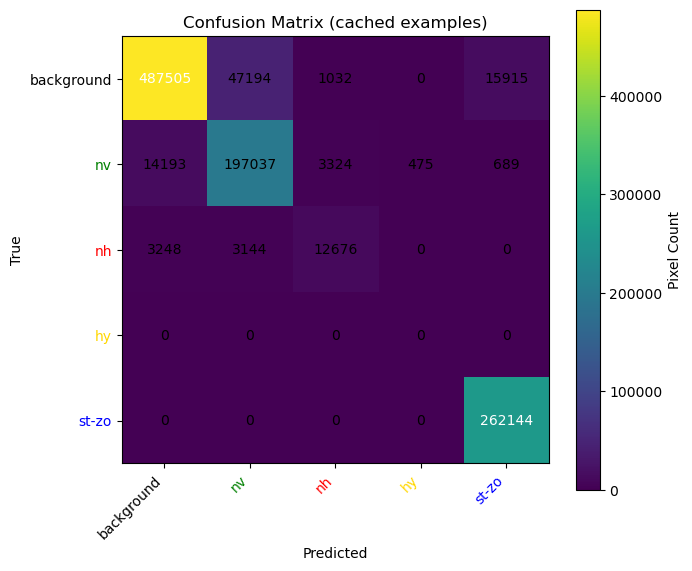

In [12]:
cm = np.zeros((num_classes, num_classes), dtype=np.int64)

flat_targets = all_targets.reshape(-1).numpy()
flat_preds = all_preds.reshape(-1).numpy()

for t, p in zip(flat_targets, flat_preds):
    cm[t, p] += 1

fig, ax = plt.subplots(figsize=(7, 6))

class_names = class_names_from_model(model)

class_colors = [
    "black",   # background
    "green",   # nv
    "red",     # nh
    "gold",    # hy
    "blue"     # st-zo
]

im = ax.imshow(cm, cmap="viridis")

ax.set_title("Confusion Matrix (cached examples)")
ax.set_xlabel("Predicted")
ax.set_ylabel("True")

ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

# 👇 Create tick labels FIRST
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)

# 👇 THEN color them
for tick, color in zip(ax.get_xticklabels(), class_colors):
    tick.set_color(color)

for tick, color in zip(ax.get_yticklabels(), class_colors):
    tick.set_color(color)

# Add numbers inside cells
for i in range(num_classes):
    for j in range(num_classes):
        val = cm[i, j]
        ax.text(
            j, i, val,
            ha="center",
            va="center",
            color="white" if val > cm.max() * 0.5 else "black"
        )

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Pixel Count")

plt.tight_layout()
plt.show()

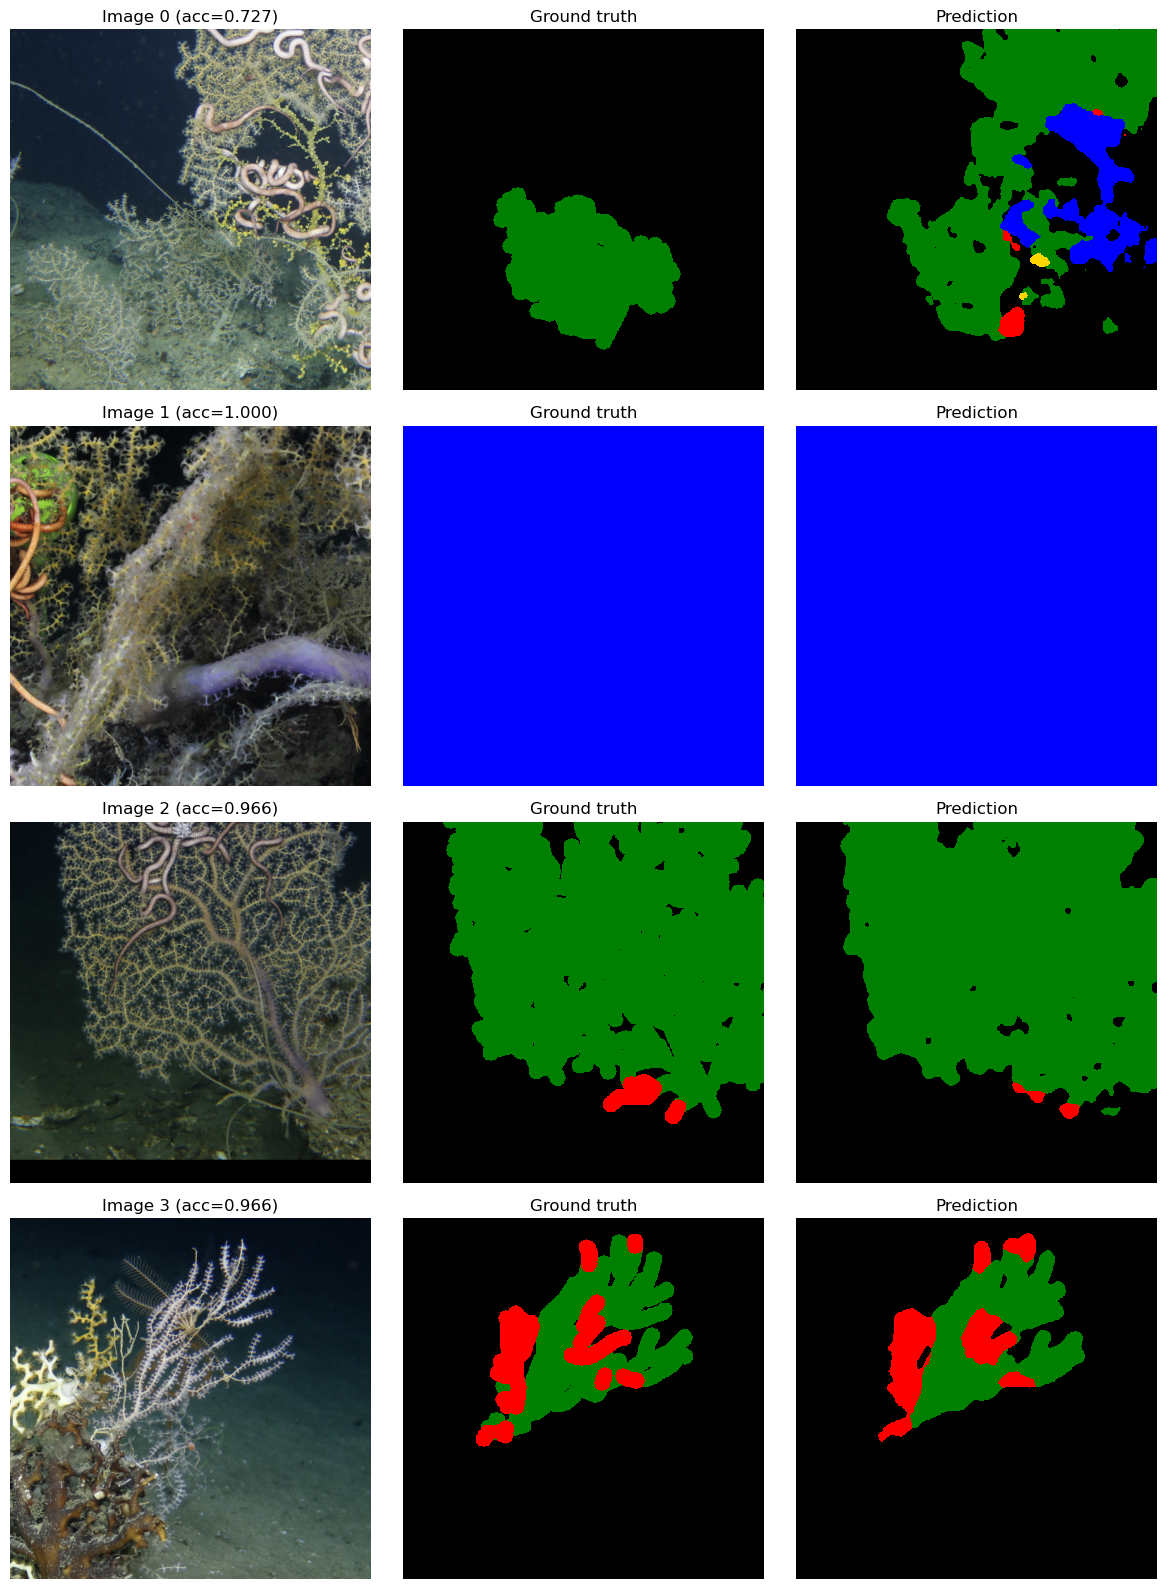

In [13]:
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "black",   # background
    "green",   # nv
    "red",     # nh
    "gold",    # hy
    "blue"     # st-zo
])

n = len(example_cache)

fig, axes = plt.subplots(n, 3, figsize=(12, 4 * n))

im1 = None

# handle case where n == 1
if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row, sample in enumerate(example_cache):
    img = denormalize_image(sample["image"])
    target = sample["target"].numpy()
    pred = sample["pred"].numpy()

    sample_acc = (sample["pred"] == sample["target"]).float().mean().item()

    axes[row, 0].imshow(img)
    axes[row, 0].set_title(f"Image {row} (acc={sample_acc:.3f})")
    axes[row, 0].axis("off")

    im1 = axes[row, 1].imshow(
        target,
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=num_classes - 1
    )
    axes[row, 1].set_title("Ground truth")
    axes[row, 1].axis("off")

    axes[row, 2].imshow(
        pred,
        cmap=cmap,
        interpolation="nearest",
        vmin=0,
        vmax=num_classes - 1
    )
    axes[row, 2].set_title("Prediction")
    axes[row, 2].axis("off")

plt.tight_layout()
plt.show()

In [14]:
def scan_dataset_for_single_class(dataloader, split_name="dataset"):
    single_class_count = 0
    total = 0

    for images, masks in dataloader:   # 👈 FIX HERE
        for mask in masks:
            unique_classes = torch.unique(mask)

            if len(unique_classes) == 1:
                single_class_count += 1
                print(f"[{split_name}] Single-class mask found: class = {unique_classes.item()}")

            total += 1

    print(f"\n[{split_name}] {single_class_count}/{total} images are single-class")

In [15]:
for j, sample in enumerate(example_cache):
    vals, counts = torch.unique(sample["target"], return_counts=True)
    print(f"Example {j} target unique values:")
    for v, c in zip(vals.tolist(), counts.tolist()):
        print(f"  class {v}: {c} pixels")

Example 0 target unique values:
  class 0: 225507 pixels
  class 1: 36637 pixels
Example 1 target unique values:
  class 4: 262144 pixels
Example 2 target unique values:
  class 0: 109766 pixels
  class 1: 148887 pixels
  class 2: 3491 pixels
Example 3 target unique values:
  class 0: 216373 pixels
  class 1: 30194 pixels
  class 2: 15577 pixels


In [16]:
single_class_count = 0
total_tiles = 0

class_counts = {i: 0 for i in range(num_classes)}

for images, masks in val_loader:
    for i in range(masks.shape[0]):
        tile = masks[i]
        unique_vals = torch.unique(tile)

        total_tiles += 1

        if len(unique_vals) == 1:
            single_class_count += 1
            class_counts[int(unique_vals.item())] += 1

print("Total tiles:", total_tiles)
print("Single-class tiles:", single_class_count)
print("Fraction single-class:", single_class_count / total_tiles)

print("\nBreakdown by class:")
for cls, count in class_counts.items():
    print(f"Class {cls}: {count}")

Total tiles: 4000
Single-class tiles: 270
Fraction single-class: 0.0675

Breakdown by class:
Class 0: 0
Class 1: 0
Class 2: 0
Class 3: 0
Class 4: 270


In [17]:
single_class_examples = []

for b_idx, (images, masks) in enumerate(val_loader):
    for i in range(masks.shape[0]):
        tile = masks[i]
        unique_vals = torch.unique(tile)

        if len(unique_vals) == 1:
            cls = int(unique_vals.item())

            single_class_examples.append({
                "image": images[i].cpu(),
                "mask": masks[i].cpu(),
                "class": cls,
                "batch_idx": b_idx,
                "tile_idx": i
            })

print("Found", len(single_class_examples), "single-class tiles")

Found 261 single-class tiles


In [19]:
class4_examples = []

for b_idx, (images, masks) in enumerate(val_loader):
    for i in range(masks.shape[0]):
        tile = masks[i]
        unique_vals = torch.unique(tile)

        if len(unique_vals) == 1 and int(unique_vals.item()) == 4:
            class4_examples.append({
                "image": images[i].cpu(),
                "mask": masks[i].cpu(),
                "batch_idx": b_idx,
                "tile_idx": i
            })

print("Found", len(class4_examples), "class-4-only tiles")

Found 262 class-4-only tiles


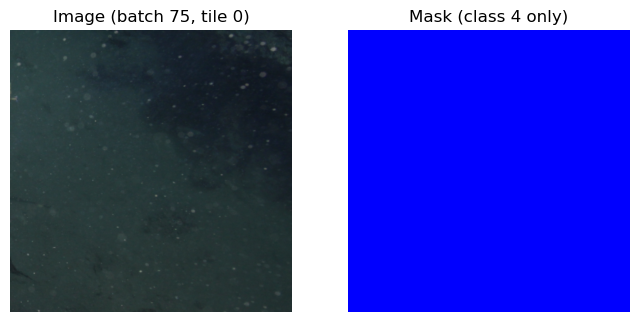

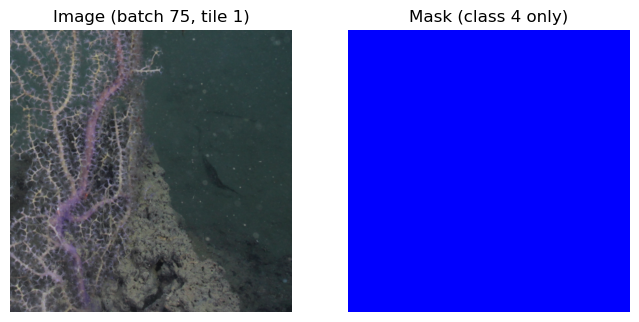

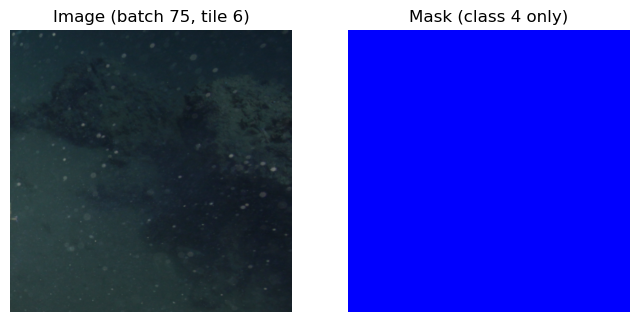

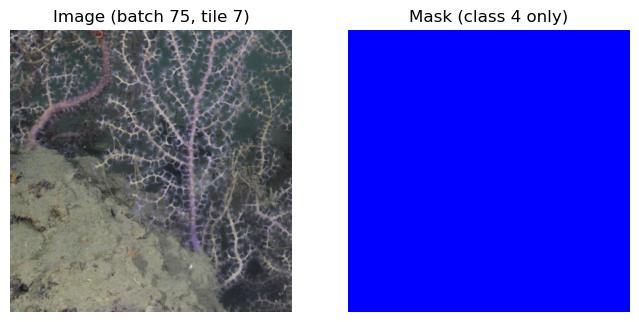

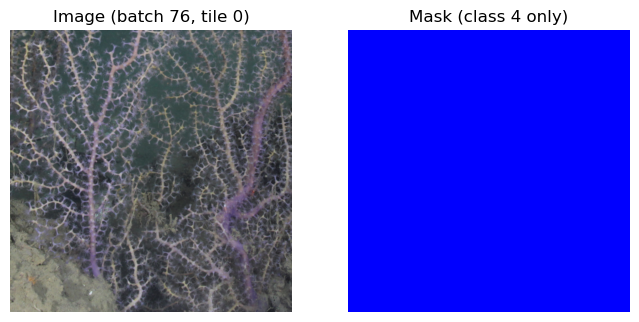

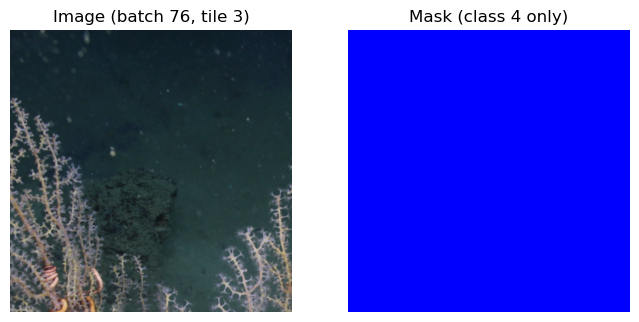

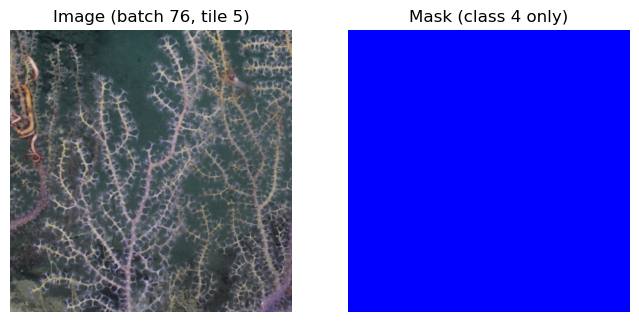

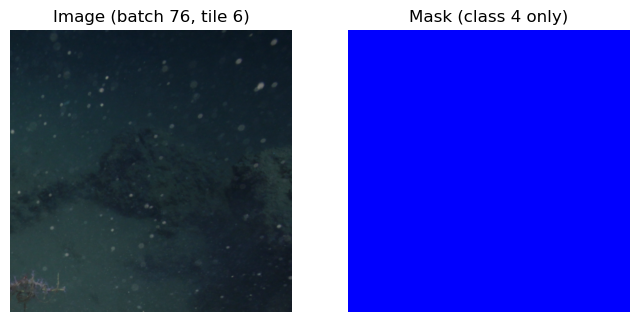

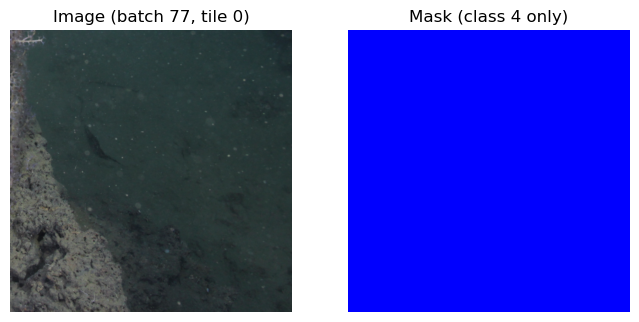

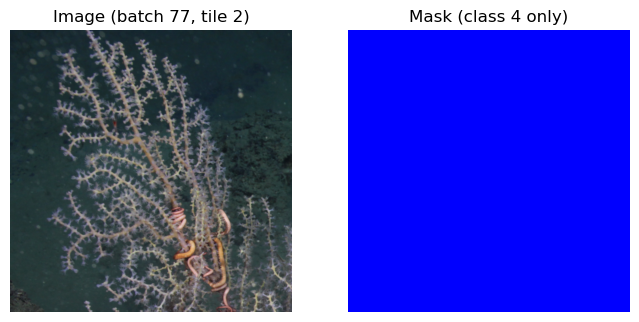

In [21]:
num_show = 10

for j in range(min(num_show, len(class4_examples))):
    sample = class4_examples[j]

    img = denormalize_image(sample["image"])
    mask = sample["mask"].numpy()

    plt.figure(figsize=(8, 4))

    plt.subplot(1, 2, 1)
    plt.imshow(img)
    plt.title(f"Image (batch {sample['batch_idx']}, tile {sample['tile_idx']})")
    plt.axis("off")

    plt.subplot(1, 2, 2)
    plt.imshow(mask, cmap=cmap, vmin=0, vmax=num_classes-1)
    plt.title("Mask (class 4 only)")
    plt.axis("off")

    plt.show()

Number of single-class masks: 24


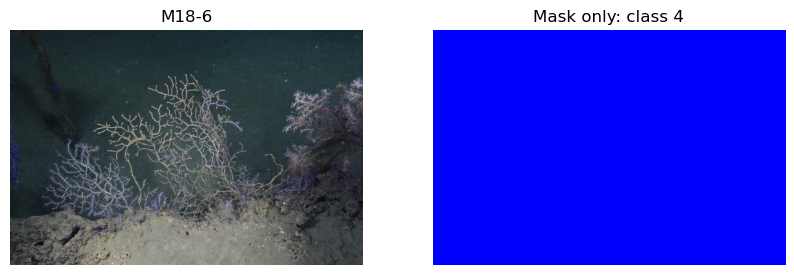

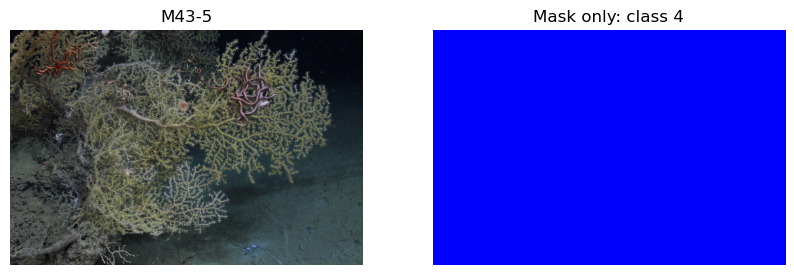

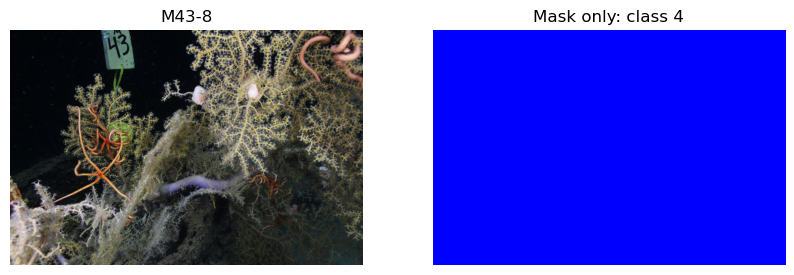

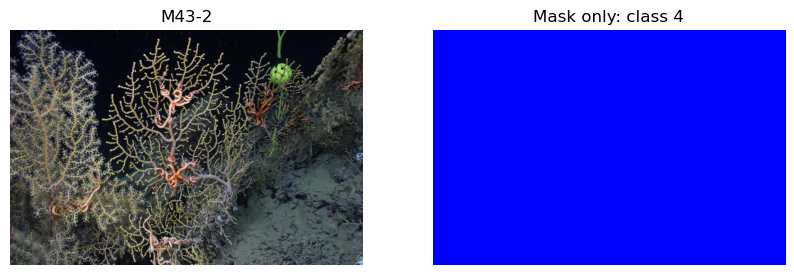

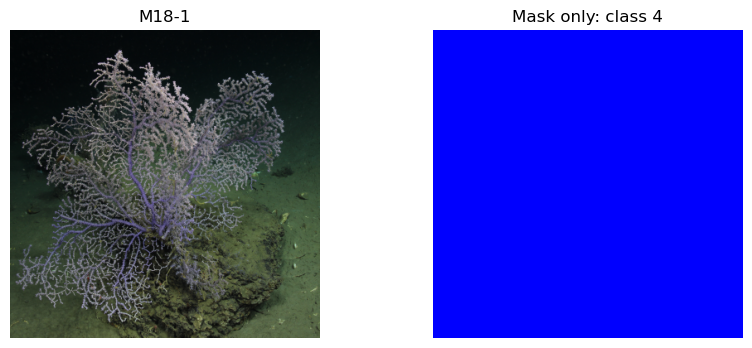

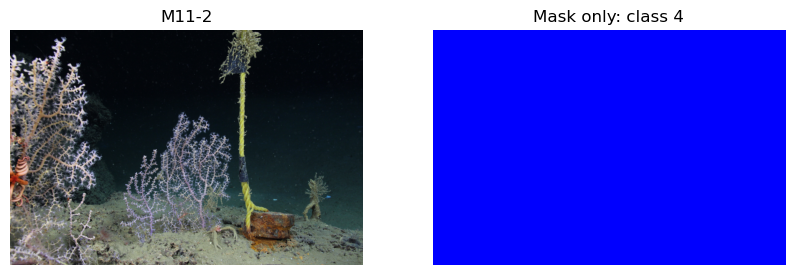

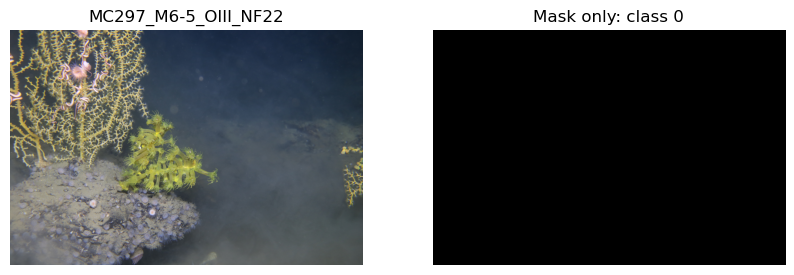

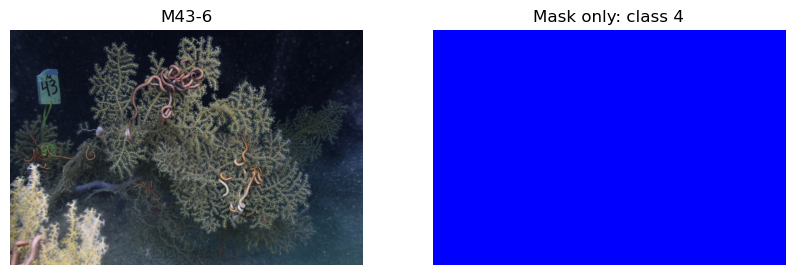

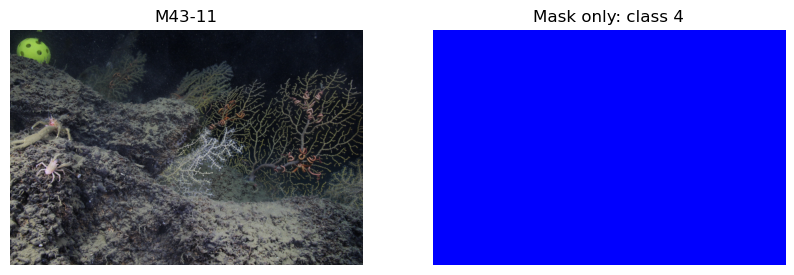

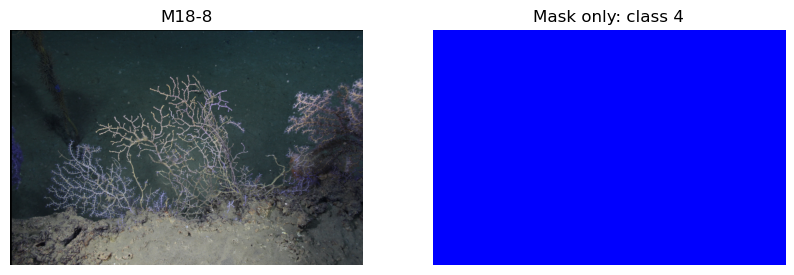

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

cmap = ListedColormap([
    "black",   # background
    "green",   # nv
    "red",     # nh
    "gold",    # hy
    "blue"     # st-zo
])

for item in single_class_masks[:10]:
    mask = np.array(Image.open(item["mask_path"]))

    plt.figure(figsize=(10, 4))

    if item["image_path"] is not None:
        image = np.array(Image.open(item["image_path"]))
        plt.subplot(1, 2, 1)
        plt.imshow(image)
        plt.title(item["folder"])
        plt.axis("off")

        plt.subplot(1, 2, 2)
    else:
        plt.subplot(1, 1, 1)

    plt.imshow(mask, cmap=cmap, vmin=0, vmax=4, interpolation="nearest")
    plt.title(f"Mask only: class {item['class']}")
    plt.axis("off")
    plt.show()

In [5]:
print("Single-class (broken) masks:\n")

for item in single_class_masks:
    print(f"{item['folder']} -> class {item['class']}")
    

Single-class (broken) masks:

M18-6 -> class 4
M43-5 -> class 4
M43-8 -> class 4
M43-2 -> class 4
M18-1 -> class 4
M11-2 -> class 4
MC297_M6-5_OIII_NF22 -> class 0
M43-6 -> class 4
M43-11 -> class 4
M18-8 -> class 4
M18-2 -> class 4
M43-1 -> class 4
M11-1 -> class 4
M11-3 -> class 4
M11-9 -> class 4
M18-10 -> class 4
M43-3 -> class 4
M43-9 -> class 4
M43-4 -> class 4
M11-4 -> class 4
M18-9 -> class 4
M43-7 -> class 4
M43-10 -> class 4
M11-7 -> class 4
